# Notebook 04 — Selección de Carteras Óptimas

**Objetivo:** Reducir las 4.000 carteras a ~40 representativas usando clustering K-Means y seleccionar la mejor por clúster mediante una puntuación compuesta.

**Puntuación compuesta:** Sharpe (40%) + Sortino (30%) + Calmar (20%) − MaxDD (10%)

**Metodología:**
1. Estandarización de características y proyección PCA 2D (visualización)
2. Selección de K óptimo por codo de inercia (rango permitido: 40-50)
3. K-Means sobre el espacio de características completo
4. Mejor cartera por clúster + óptimo global

**Outputs:**
- `selected_portfolios.parquet` — composición de las carteras seleccionadas
- `selected_portfolios_ids.json` — lista de IDs
- `optimal_selection_details_v4.parquet` — puntuaciones por clúster

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
np.random.seed(42)

def _resolve_root():
    cwd = Path.cwd().resolve()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'data').exists() and (c / 'src').exists(): return c
    return cwd

ROOT          = _resolve_root()
sys.path.insert(0, str(ROOT))
PROCESSED_DIR = ROOT / 'data' / 'processed'
FIG_DIR       = ROOT / 'data' / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Project root: {ROOT}')

Project root: C:\Users\Usuario\Documents\TFG\tfg_xiker_code


## 1. Carga de datos

In [2]:
features    = pd.read_parquet(PROCESSED_DIR / 'portfolios_features.parquet')
composition = pd.read_parquet(PROCESSED_DIR / 'portfolios_composition.parquet')
print(f'Características: {features.shape}  Composición: {composition.shape}')
features.head(3)

Características: (4000, 16)  Composición: (41608, 3)


,portfolio_id,annual_return,annual_volatility,sharpe_ratio,max_drawdown,sortino_ratio,calmar_ratio,skewness,kurtosis,beta,n_assets,hhi,pct_equity,pct_fixed_income,pct_commodities,pct_reits
0,1,0.052390,0.044817,1.168967,-0.130467,1.605775,0.401558,-0.138072,6.243440,0.106746,9,0.209751,0.146061,0.739600,0.114338,0.0
1,2,0.141196,0.138698,1.018015,-0.312477,1.360153,0.451862,-0.104152,7.408802,0.482989,5,0.286766,0.575558,0.083987,0.340456,0.0
2,3,0.110947,0.109190,1.016087,-0.279369,1.366309,0.397133,-0.224256,5.901590,0.354613,6,0.251858,0.314372,0.425131,0.260497,0.0


## 2. Estandarización y proyección PCA

In [3]:
from src.nb04_selection import standardize_features, run_pca

X, scaler, feature_cols = standardize_features(features)
X_pca, pca              = run_pca(X)
print(f'Varianza explicada PCA: {pca.explained_variance_ratio_.round(3)}')

PCA explained variance: [0.335 0.251]
Varianza explicada PCA: [0.335 0.251]


## 3. Selección del número óptimo de clústeres

Se evalúan K de 5 a 50 usando el método del codo sobre la inercia. Se impone K ∈ [40, 50] para garantizar diversidad suficiente en las carteras seleccionadas:

In [4]:
from src.nb04_selection import select_optimal_k

optimal_k, metrics_df = select_optimal_k(X)
print(f'\nK óptimo seleccionado: {optimal_k}')
metrics_df.round(4)

  K=  5: Sil=0.1454  DB=1.7489
  K= 10: Sil=0.1408  DB=1.5466
  K= 15: Sil=0.1276  DB=1.5514
  K= 20: Sil=0.1254  DB=1.5613
  K= 25: Sil=0.1190  DB=1.6283
  K= 30: Sil=0.1168  DB=1.6322
  K= 35: Sil=0.1175  DB=1.5887
  K= 40: Sil=0.1152  DB=1.6346
  K= 45: Sil=0.1146  DB=1.6368
  K= 50: Sil=0.1132  DB=1.6285
Elbow K=20  Selected K=40

K óptimo seleccionado: 40


,k,inertia,silhouette,db_score
0,5,33669.8240,0.1454,1.7489
1,10,25946.8894,0.1408,1.5466
2,15,22433.5063,0.1276,1.5514
3,20,20377.2214,0.1254,1.5613
4,25,19050.9812,0.1190,1.6283
5,30,17961.3043,0.1168,1.6322
6,35,17066.3711,0.1175,1.5887
7,40,16330.8312,0.1152,1.6346
8,45,15678.0841,0.1146,1.6368
9,50,15175.2216,0.1132,1.6285


**Interpretación:** La silhouette score mide la cohesión interna de los clústeres (mayor = mejor separación). El Davies-Bouldin score penaliza la similitud entre clústeres (menor = mejor). El método del codo identifica el punto donde añadir más clústeres aporta poca reducción de inercia.

## 4. Clustering final K-Means

In [5]:
from src.nb04_selection import fit_kmeans

cluster_labels = fit_kmeans(X, optimal_k)
print(f'Distribución de clústeres:')
pd.Series(cluster_labels).value_counts().sort_index().describe()

K-Means K=40  Inertia=16330.8
Distribución de clústeres:


count     40.000000
mean     100.000000
std       47.071141
min       10.000000
25%       65.250000
50%       89.000000
75%      131.000000
max      216.000000
Name: count, dtype: float64

## 5. Puntuación compuesta y selección

In [6]:
from src.nb04_selection import compute_composite_scores, select_portfolios

score_df = compute_composite_scores(features, cluster_labels)
selected_ids, details_df = select_portfolios(score_df, optimal_k)
print(f'\nTop 5 carteras por puntuación compuesta:')
details_df.nlargest(5, 'composite_score')[['cluster','portfolio_id','sharpe_ratio','composite_score']].round(4)

Composite score: [-1.3980, 4.6565]
  Cluster  0: pid=1587  score=0.0049
  Cluster  1: pid=1267  score=0.1390
  Cluster  2: pid=74  score=1.8225
  Cluster  3: pid=144  score=1.9244
  Cluster  4: pid=525  score=1.2696
  Cluster  5: pid=698  score=0.6381
  Cluster  6: pid=1146  score=0.2808
  Cluster  7: pid=291  score=1.3505
  Cluster  8: pid=55  score=1.9713
  Cluster  9: pid=164  score=1.8325
  Cluster 10: pid=234  score=1.2033
  Cluster 11: pid=1617  score=-0.0751
  Cluster 12: pid=1501  score=0.2697
  Cluster 13: pid=1104  score=0.1700
  Cluster 14: pid=31  score=2.3950
  Cluster 15: pid=6  score=3.0963
  Cluster 16: pid=1003  score=0.4045
  Cluster 17: pid=2  score=3.7982
  Cluster 18: pid=154  score=1.8882
  Cluster 19: pid=924  score=0.4791
  Cluster 20: pid=86  score=2.6674
  Cluster 21: pid=1420  score=0.2981
  Cluster 22: pid=351  score=1.1812
  Cluster 23: pid=79  score=1.8015
  Cluster 24: pid=838  score=0.6965
  Cluster 25: pid=1260  score=0.0225
  Cluster 26: pid=1504  scor

,cluster,portfolio_id,sharpe_ratio,composite_score
30,30,1,1.1690,4.6565
17,17,2,1.0180,3.7982
15,15,6,0.9996,3.0963
20,20,86,0.8668,2.6674
14,14,31,0.9219,2.3950


**Interpretación:** La puntuación compuesta equilibra cuatro dimensiones de calidad de la cartera. El Sharpe (40%) y Sortino (30%) dominan la selección, pero el Calmar ratio y el MaxDD garantizan que las carteras seleccionadas también tengan un perfil de drawdown controlado. Esto evita seleccionar carteras con Sharpe alto pero pérdidas máximas excesivas.

## 6. Visualización: clusters y selección final

Saved: C:\Users\Usuario\Documents\TFG\tfg_xiker_code\data\results\figures\04_cluster_selection_v4.png


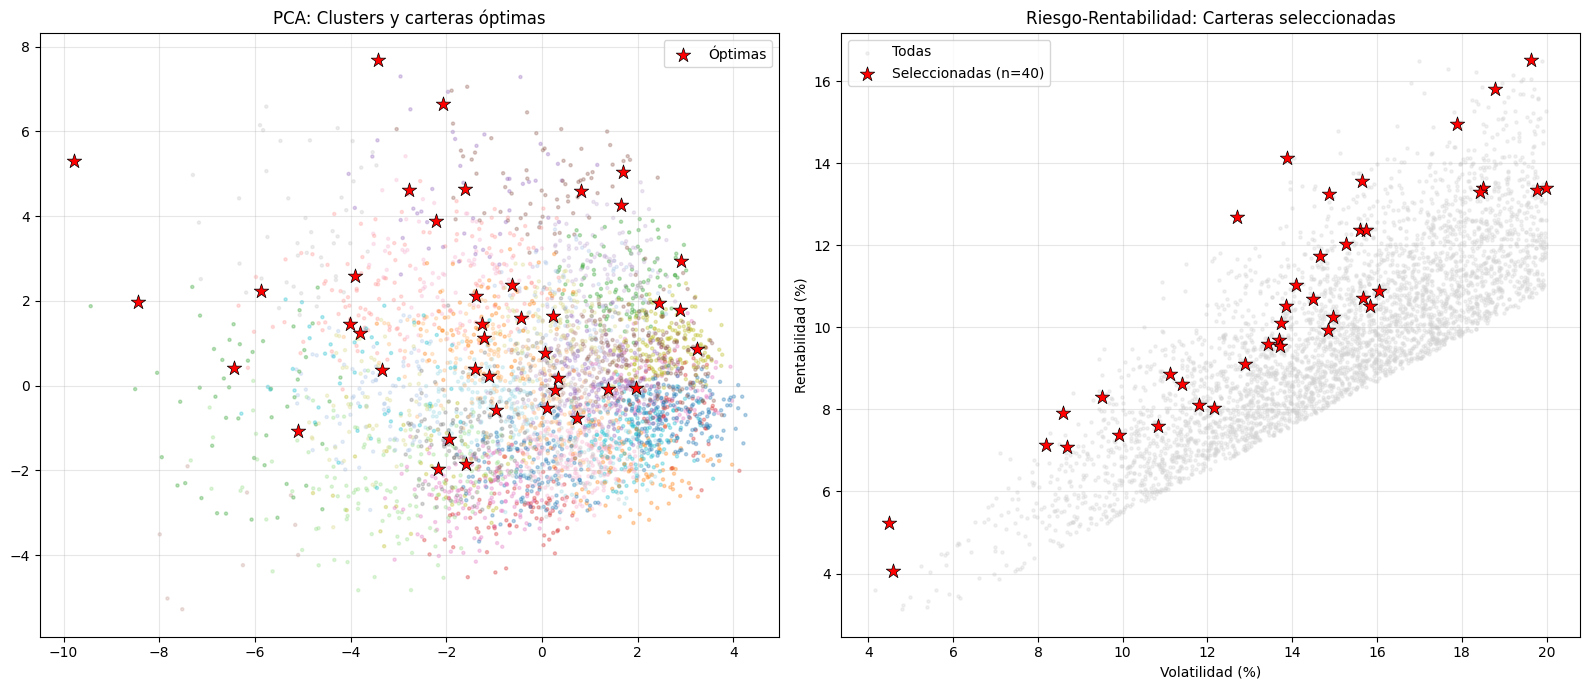

In [7]:
from src.nb04_selection import plot_selection

fig = plot_selection(features, X_pca, cluster_labels, selected_ids, FIG_DIR)
plt.show()

**Interpretación:** El panel izquierdo muestra la proyección PCA con cada clúster en un color diferente. Las estrellas rojas marcan las carteras seleccionadas (una por clúster), distribuidas por todo el espacio de características. El panel derecho confirma que las carteras seleccionadas cubren todo el espectro riesgo-rentabilidad del universo original, proporcionando una muestra representativa y diversa.

## 7. Composición por clase de activo

Cada barra es una cartera seleccionada, ordenadas de mayor a menor peso en renta fija (izquierda = más conservadora, derecha = más agresiva). Las etiquetas muestran el porcentaje cuando el segmento supera el 8%.

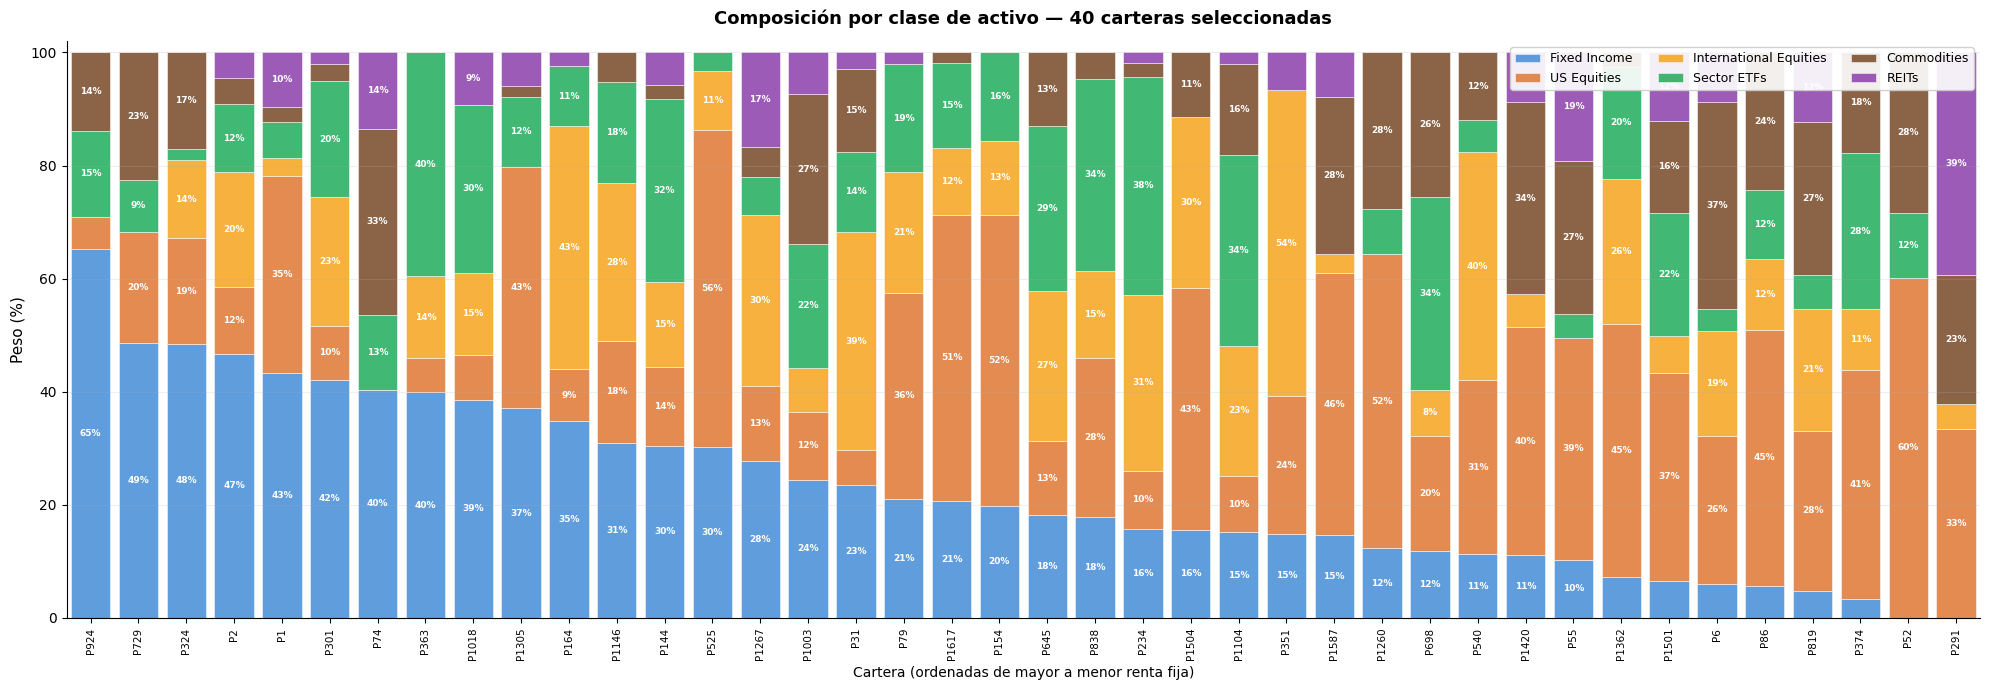

[OK] 04_composicion_clases_activo.png


In [8]:
import json as _json
import numpy as np

# Mapa ticker → clase de activo
_meta        = _json.loads((PROCESSED_DIR / 'asset_universe.json').read_text())
_ticker_cls  = _meta['asset_classes']   # {ticker: 'US Equities', ...}

# Filtrar composición a las carteras seleccionadas
_comp = composition.copy()
_comp['portfolio_id'] = _comp['portfolio_id'].astype(int)
_comp['asset_class']  = _comp['ticker'].map(_ticker_cls).fillna('Other')
_sel  = _comp[_comp['portfolio_id'].isin([int(x) for x in selected_ids])]

# Peso por (portfolio_id, clase)
_agg = (_sel.groupby(['portfolio_id', 'asset_class'])['weight']
            .sum().unstack(fill_value=0))

_CLASS_ORDER = ['Fixed Income', 'US Equities', 'International Equities',
                'Sector ETFs', 'Commodities', 'REITs']
_CLASS_ORDER = [c for c in _CLASS_ORDER if c in _agg.columns] + \
               [c for c in _agg.columns if c not in _CLASS_ORDER]
_agg = _agg[_CLASS_ORDER].sort_values('Fixed Income', ascending=False)

_COLORS = {'Fixed Income': '#4a90d9', 'US Equities': '#e07b39',
           'International Equities': '#f5a623', 'Sector ETFs': '#27ae60',
           'Commodities': '#7b4f2e', 'REITs': '#8e44ad', 'Other': '#95a5a6'}

fig, ax = plt.subplots(figsize=(20, 7))
_bottom = np.zeros(len(_agg))
for _cls in _CLASS_ORDER:
    _vals = _agg[_cls].values * 100
    ax.bar(range(len(_agg)), _vals, bottom=_bottom,
           label=_cls, color=_COLORS.get(_cls, '#bdc3c7'),
           alpha=0.88, width=0.82, edgecolor='white', linewidth=0.4)
    for _i, (_v, _b) in enumerate(zip(_vals, _bottom)):
        if _v > 8:
            ax.text(_i, _b + _v / 2, f'{_v:.0f}%',
                    ha='center', va='center', fontsize=6.5,
                    color='white', fontweight='bold')
    _bottom += _vals

ax.set_xlim(-0.5, len(_agg) - 0.5)
ax.set_ylim(0, 102)
ax.set_xticks(range(len(_agg)))
ax.set_xticklabels(['P' + str(int(r)) for r in _agg.index], rotation=90, fontsize=7.5)
ax.set_ylabel('Peso (%)', fontsize=11)
ax.set_xlabel('Cartera (ordenadas de mayor a menor renta fija)', fontsize=10)
ax.set_title(
    'Composición por clase de activo — ' + str(len(_agg)) + ' carteras seleccionadas',
    fontsize=13, fontweight='bold', pad=12
)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9, ncol=3)
ax.grid(axis='y', alpha=0.2, linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
_out = FIG_DIR / '04_composicion_clases_activo.png'
plt.savefig(_out, dpi=150, bbox_inches='tight')
plt.show()
print('[OK]', _out.name)


## 8. Guardado de outputs

In [9]:
from src.nb04_selection import save_outputs

save_outputs(selected_ids, details_df, composition, cluster_labels, features, scaler, PROCESSED_DIR)
print(f'\n✓ NB04 COMPLETO — {len(selected_ids)} carteras óptimas seleccionadas de {len(features)} candidatas')

Saved: selected_portfolios.parquet | selected_portfolios_ids.json
       cluster_labels.parquet | optimal_selection_details_v4.parquet

✓ NB04 COMPLETO — 40 carteras óptimas seleccionadas de 4000 candidatas
